# DBSCAN: 
**Density-Based Spatial Clustering of Applications with Noise**

In [47]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Activate dark theme
plt.style.use('dark_background')

# create sample data of 300 points
X, _ = make_blobs(n_samples=300, centers=3, random_state=42)
X[:5]

array([[-7.33898809, -7.72995396],
       [-7.74004056, -7.26466514],
       [-1.68665271,  7.79344248],
       [ 4.42219763,  3.07194654],
       [-8.91775173, -7.8881959 ]])

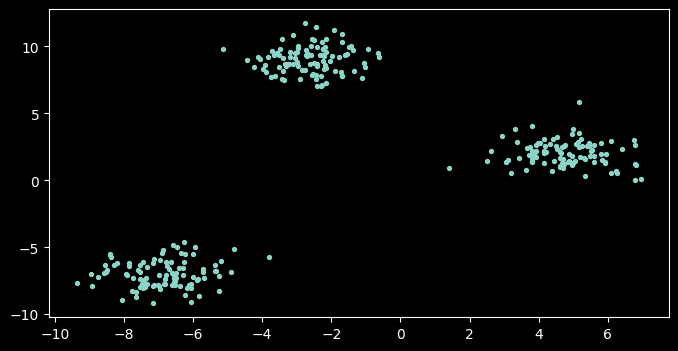

In [48]:
# plot
plt.figure(figsize=(8, 4))
plt.scatter(X[:,0], X[:,1], s=8)
plt.show()

k_distances (1st 10) : [0.05624496 0.05757439 0.05757439 0.07491427 0.08139312 0.09443877
 0.09580455 0.09681847 0.09831184 0.09962909]
k_distances (last 10): [0.83151971 0.84001718 0.93104098 0.94543383 1.06150889 1.14498441
 1.19615443 1.41193168 1.70079883 2.20826092]


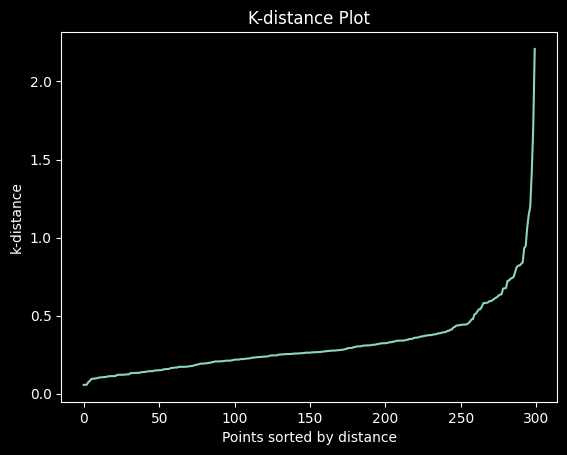

In [39]:
# Finding epsilon

from sklearn.neighbors import NearestNeighbors
import numpy as np

k = 3   # should be same as MinPts

# compute nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

# take kth distance: How far is the k-th nearest neighbor
k_distances = distances[:, k-1]

# sort distances
k_distances = np.sort(k_distances)
print("k_distances (1st 10) :", k_distances[:10])   # distance is small
print("k_distances (last 10):", k_distances[-10:]) # distance is large

# plot
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("k-distance")
plt.title("K-distance Plot")
plt.show()

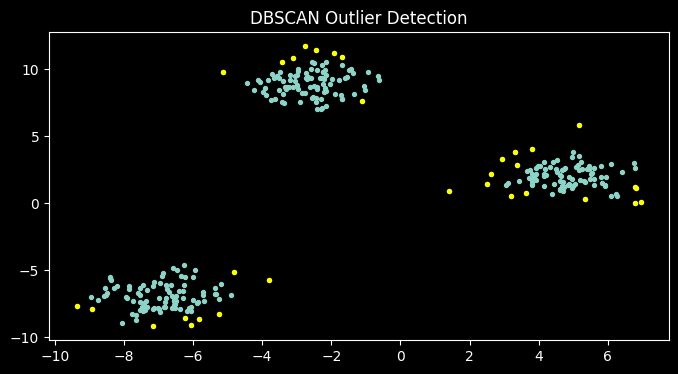

In [50]:
# apply DBSCAN
db = DBSCAN(eps=0.5, min_samples=3) # change min_samples = 2, 3, 4, 5
labels = db.fit_predict(X)

# outliers have label = -1
outliers = X[labels == -1]

# plot
plt.figure(figsize=(8, 4))
plt.scatter(X[:,0], X[:,1], s=8)
plt.scatter(outliers[:,0], outliers[:,1], color='yellow', s=8)
plt.title("DBSCAN Outlier Detection")
plt.show()


In [41]:
outliers

array([[-8.91775173, -7.8881959 ],
       [-3.11090424, 10.86656431],
       [ 2.61473625,  2.159624  ],
       [-1.92234053, 11.20474175],
       [ 3.82165815,  4.06555696],
       [ 5.15492652,  5.82590117],
       [ 6.77291221,  0.02108188],
       [-3.80074638, -5.76053468],
       [-5.8212027 , -8.63884908],
       [ 6.79306129,  1.20582212],
       [ 5.32613903,  0.36045381],
       [ 2.92674431,  3.32704206],
       [ 3.63386145,  0.75898107],
       [-1.10640331,  7.61243507],
       [-4.81887927, -5.12476875],
       [-6.24103473, -8.54162966],
       [-5.12894273,  9.83618863],
       [-2.44896741, 11.47752824],
       [-3.42862186, 10.56422053],
       [-2.77385446, 11.73445529],
       [-9.35127169, -7.67700485],
       [ 1.3986115 ,  0.94878204],
       [-5.25101165, -8.26021105],
       [ 3.31964563,  3.80462845],
       [ 3.37899488,  2.89103163],
       [-7.15467889, -9.18203076],
       [-6.05022161, -9.0912449 ],
       [ 2.51598311,  1.44741466],
       [-1.68713746,